#Data Retrieval and Data Wrangling/Cleaning  



## Project sections  

1. **Data Retrieval**  
   - Documentation of data source  
   - Data acquisition and loading  
   - Storage of raw data in original format  
   - Basic validation of retrieved data  

2. **Data Wrangling/Cleaning**  
   - Initial data audit (missing values, duplicates, inconsistencies)  
   - Use of `quantDDA()` and `vizDDA()` for exploratory diagnostics  
   - Data cleaning and preprocessing  
   - Construction of a reproducible wrangling pipeline  
   - Preparation of cleaned dataset for EDA and modeling

## Data Source Documentation

### 1. Dataset Origin

The dataset used in this project is the **New York City Taxi & Limousine Commission (TLC) – High Volume For-Hire Vehicles (HVFHV) Trip Record Data**.

- Source: NYC Taxi & Limousine Commission (TLC)
- Dataset: High Volume For-Hire Vehicles (HVFHV) Trip Records
- Website: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
- Months used: December 2025 and January 2026
- Date accessed: February 24th, 2026

The TLC provides publicly available trip-level data for high-volume for-hire vehicle services (e.g., rideshare platforms operating under TLC regulation).

The dataset was accessed programmatically using the NYC Open Data API (Socrata) instead of direct file downloads. A custom data retrieval function was implemented to query the High Volume For-Hire Vehicle (HVFHV) dataset using HTTP requests.

The API was used to filter records by date range for December 2025 and January 2026, while selecting only the relevant features required for the analysis. Due to API constraints on response size, the data was retrieved in batches using pagination with limit and offset parameters. Each batch was appended and combined into a single DataFrame for each month.

---

### 2. Dataset Description

The dataset contains trip-level records for HVFHV rides in New York City. Each row represents a single trip and includes:

- Request, pickup, and drop-off timestamps
- Trip distance
- Pickup and drop-off location IDs
- Dispatching and originating base numbers
- Shared ride indicators
- Other operational trip attributes

The combined December 2025 and January 2026 datasets contain tens of millions of trip records, making this a large-scale dataset appropriate for data-intensive analysis.

---

### 3. Data Format and Structure

The data was provided in Parquet format.

- Each row corresponds to one HVFHV trip.
- Each column represents a trip attribute.
- The dataset is structured as a large tabular dataset with both numerical and categorical variables.

Raw data files were stored in their original format before any transformations were applied to ensure reproducibility and traceability of preprocessing steps.

---

### 4. Justification for Use

This dataset is appropriate for the project because:

- It satisfies the large-scale data requirement (millions of observations).
- It contains both numerical and categorical variables suitable for statistical analysis.
- It allows formulation of supervised learning problems (e.g., predicting trip duration or other continuous variables).
- It supports unsupervised analysis (e.g., clustering ride patterns by time or location).
- It represents real-world transportation data with practical analytical value.

The December 2025 and January 2026 data provide recent, consecutive monthly observations, enabling temporal comparison and pattern analysis.

#1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pyarrow
import urllib.parse
import time

#2. Loading Data

Reading the two raw data set and combining them to get a dataset > 1GB

In [ ]:
def load_month_api(start_date, end_date, limit_total=200000, chunk_size=50000):
    base_url = "https://data.cityofnewyork.us/resource/r67x-e97r.json"

    all_parts = []

    for offset in range(0, limit_total, chunk_size):
        query = {
            "$select": ",".join([
                "trip_miles",
                "trip_time",
                "base_passenger_fare",
                "tips",
                "driver_pay",
                "pickup_datetime"
            ]),
            "$where": f"pickup_datetime >= '{start_date}' AND pickup_datetime < '{end_date}'",
            "$limit": chunk_size,
            "$offset": offset
        }

        url = base_url + "?" + urllib.parse.urlencode(query)
        part = pd.read_json(url)

        if part.empty:
            break

        all_parts.append(part)
        time.sleep(0.5)  # avoid getting rate-limited

    df = pd.concat(all_parts, ignore_index=True)
    return df

    df_1 = load_month_api(
    "2025-12-01T00:00:00",
    "2026-01-01T00:00:00"
)

print(df_1.shape)


df_2 = load_month_api(
    "2026-01-01T00:00:00",
    "2026-02-01T00:00:00"
)

print(df_2.shape)

In [ ]:
# Read both raw data files
#url = "https://data.cityofnewyork.us/resource/r67x-e97r.json?$limit=5000"
#df = pd.read_json(url)
#df_1 = pd.read_parquet("raw_data/fhvhv_tripdata_2025-12.parquet")
#df_2 = pd.read_parquet("raw_data/fhvhv_tripdata_2026-01.parquet")

#print("File 1 shape:", df_1.shape)
#print("File 2 shape:", df_2.shape)

# Combine
df = pd.concat([df_1, df_2], ignore_index=True)

print("Combined shape:", df.shape)

# Save combined version
df.to_parquet("processed_data/tripdata_2025_12_2026_01.parquet", index=False)

print("Combined file saved successfully!")

File 1 shape: (22108438, 25)
File 2 shape: (20940373, 25)
Combined shape: (43048811, 25)
Combined file saved successfully!


#3. Information on Raw Data

Getting the information of the combined datasets

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43048811 entries, 0 to 43048810
Data columns (total 25 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     str           
 1   dispatching_base_num  str           
 2   originating_base_num  str           
 3   request_datetime      datetime64[us]
 4   on_scene_datetime     datetime64[us]
 5   pickup_datetime       datetime64[us]
 6   dropoff_datetime      datetime64[us]
 7   PULocationID          int32         
 8   DOLocationID          int32         
 9   trip_miles            float64       
 10  trip_time             int64         
 11  base_passenger_fare   float64       
 12  tolls                 float64       
 13  bcf                   float64       
 14  sales_tax             float64       
 15  congestion_surcharge  float64       
 16  airport_fee           float64       
 17  tips                  float64       
 18  driver_pay            float64       
 19  shared_re

#4. Processing Missing Values

Checking for missing values

In [ ]:
df.isnull().sum().sort_values(ascending=False)

originating_base_num    11791229
hvfhs_license_num              0
dispatching_base_num           0
request_datetime               0
on_scene_datetime              0
pickup_datetime                0
dropoff_datetime               0
PULocationID                   0
DOLocationID                   0
trip_miles                     0
trip_time                      0
base_passenger_fare            0
tolls                          0
bcf                            0
sales_tax                      0
congestion_surcharge           0
airport_fee                    0
tips                           0
driver_pay                     0
shared_request_flag            0
shared_match_flag              0
access_a_ride_flag             0
wav_request_flag               0
wav_match_flag                 0
cbd_congestion_fee             0
dtype: int64

Missing Values Analysis: Calculating the percentage of missing values in originating_base_num

In [ ]:
missing_pct = df["originating_base_num"].isnull().mean() * 100
print(f"{missing_pct:.2f}% missing")

27.39% missing


Since at this stage of the analysis we do not know if originating_base_num column is useful or not, we do not drop it. instead, we fill-in the missing values for this column with "UNKNOWN"

In [ ]:
df["originating_base_num"] = df["originating_base_num"].fillna("UNKNOWN")

#5. Processing Duplicates

Checking for duplicates and dropping the duplicate rows
Since duplicate records can bias modeling results, we removed it.

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates$()

print("New shape:", df.shape)

New shape: (43048810, 25)


#5. validity constraints

- taxi trips cannot have negative values for trip miles, trip time, or base passenger fare

In [ ]:
print("Trip miles <= 0:", (df["trip_miles"] <= 0).sum())
print("Trip time <= 0:", (df["trip_time"] <= 0).sum())
print("Base fare <= 0:", (df["base_passenger_fare"] <= 0).sum())

Trip miles <= 0: 5139
Trip time <= 0: 739
Base fare <= 0: 135730


In [ ]:
# calculating the percentage of the non-valid negative values for different attributes
total = len(df)

print("Trip miles <= 0: {:.4f}%".format(5139 / total * 100))
print("Trip time <= 0: {:.4f}%".format(739 / total * 100))
print("Base fare <= 0: {:.4f}%".format(135730 / total * 100))

Trip miles <= 0: 0.0119%
Trip time <= 0: 0.0017%
Base fare <= 0: 0.3153%


In [ ]:
# trip_miles ≤ 0: Trips cannot have 0 or negative miles --> removed
# trip_time ≤ 0: Trips cannot have 0 or negative duration --> Remove
df = df[(df["trip_miles"] > 0) & (df["trip_time"] > 0)]
print("New shape after removing invalid trips:", df.shape)

New shape after removing invalid trips: (43043670, 25)


In [ ]:
# base_passenger_fare ≤ 0: Could fare = 0 be: Cancelled trips or Special program or Data recording issue
print(df[df["base_passenger_fare"] <= 0].head())
df[df["base_passenger_fare"] <= 0][["trip_miles", "trip_time", "tips"]].describe()

      hvfhs_license_num dispatching_base_num originating_base_num  \
3557             HV0003               B03404               B03404   
21878            HV0003               B03404               B03404   
28334            HV0003               B03404               B03404   
40566            HV0003               B03404               B03404   
56014            HV0003               B03404               B03404   

         request_datetime   on_scene_datetime     pickup_datetime  \
3557  2025-12-01 00:11:03 2025-12-01 00:16:58 2025-12-01 00:16:58   
21878 2025-12-01 01:41:53 2025-12-01 01:43:44 2025-12-01 01:44:51   
28334 2025-12-01 02:09:24 2025-12-01 02:11:56 2025-12-01 02:12:29   
40566 2025-12-01 04:16:18 2025-12-01 04:18:38 2025-12-01 04:20:11   
56014 2025-12-01 05:05:00 2025-12-01 04:57:21 2025-12-01 05:00:13   

         dropoff_datetime  PULocationID  DOLocationID  trip_miles  ...  \
3557  2025-12-01 00:23:38           215           205        1.76  ...   
21878 2025-12-01 01:47

,trip_miles,trip_time,tips
count,135466.000000,135466.000000,135466.000000
mean,4.419190,1093.180340,0.135424
std,6.254602,911.840274,1.125532
min,0.010000,9.000000,0.000000
25%,1.325000,544.000000,0.000000
50%,2.497000,877.000000,0.000000
75%,5.090000,1397.000000,0.000000
max,513.730000,47657.000000,54.590000


Some trips have zero base fare but positive distance and duration. These are likely promotional, adjusted, or contract-based rides. Therefore, they were retained in the dataset.

#6. Feature Engineering

Creating a trip_duration feature using timestamps even though we have trip_time to verify consistency

In [ ]:
df["calculated_trip_time"] = (
    df["dropoff_datetime"] - df["pickup_datetime"]
).dt.total_seconds()

# ensuring the trip times are values (positive values)
(df["calculated_trip_time"] <= 0).sum()

np.int64(1)

#7. Dropping Invalid/Useless Rows/Columns and Downcasting

In [ ]:
# Droping the single row where dropoff <= pickup (invalid duration)
df = df[df["calculated_trip_time"] > 0]

print("New shape:", df.shape)

New shape: (43043669, 26)


In [ ]:
# Drop the helper column
df = df.drop(columns=["calculated_trip_time"])

We validated timestamp consistency by computing trip duration from pickup/dropoff.
We removed the single record where dropoff time was not after pickup time.

Downcast Numeric Columns as righ now we are using more that 8 GB memory:

Convert float64 → float32

Convert int64 → int32 (if safe)

In [ ]:
# Downcast floats
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# Downcast ints
int_cols = df.select_dtypes(include=["int64"]).columns
df[int_cols] = df[int_cols].astype("int32")

print("Memory after downcasting (GB):",
      df.memory_usage(deep=True).sum() / (1024**3))

Memory after downcasting (GB): 7.226738282479346


#8. Saving Cleaned Data

Save the full cleaned Dataset

In [ ]:
df.to_parquet(
    "processed_data/tripdata_clean_full.parquet",
    index=False,
    compression="snappy"
)

print("Full cleaned dataset saved.")

Create Smaller EDA Subset (5M random samples)

In [ ]:
df_eda = df.sample(n=5_000_000, random_state=42)

print("EDA subset shape:", df_eda.shape)

Save EDA Subset

In [ ]:
df_eda.to_parquet(
    "processed_data/tripdata_clean_eda_5M.parquet",
    index=False,
    compression="snappy"
)

print("EDA subset saved.")

#9. Quantitative Description

**Quantitative Descriptions (quantDDA())**

In [ ]:
def quantDDA(df):
    stats_cols = [
        "num_observations",
        "num_entries",
        "num_unique",
        "num_missing",
        "num_outliers",
        "num_extreme_1pct",
        "modes",
        "mean",
        "std",
        "max",
        "min",
        "Q1",
        "Q2",
        "Q3",
        "skewness",
        "kurtosis"
    ]

    summary_df = pd.DataFrame(index=df.columns, columns=stats_cols)

    n_entries = len(df)

    for col in df.columns:
        s = df[col]

        # Stats that are valid for both numerical and nun-numberical values
        summary_df.loc[col, "num_entries"] = n_entries
        summary_df.loc[col, "num_observations"] = s.count()
        summary_df.loc[col, "num_missing"] = s.isna().sum()
        summary_df.loc[col, "num_unique"] = s.nunique(dropna=True)

        # Since there may be more than one mode, we store them as comma-separated string
        modes = s.mode(dropna=True)
        summary_df.loc[col, "modes"] = ", ".join(map(str, modes.tolist())) if len(modes) else ""

        # Put the default value for the other columns to be NaN, to be handle the non-numerical data which do not have the fallowing stats
        summary_df.loc[col, ["mean","std","max","min","Q1","Q2","Q3","skewness","kurtosis",
                             "num_outliers","num_extreme_1pct"]] = np.nan

        # Calculating the stats that are only meaningful for the numberical data
        if pd.api.types.is_numeric_dtype(s):
            sn = s.dropna() # Dropping NaN values from the column
            if len(sn) > 0:
                summary_df.loc[col, "mean"] = sn.mean()
                summary_df.loc[col, "std"] = sn.std(ddof=1)
                summary_df.loc[col, "max"] = sn.max()
                summary_df.loc[col, "min"] = sn.min()

                q1 = sn.quantile(0.25)
                q2 = sn.quantile(0.50)
                q3 = sn.quantile(0.75)
                summary_df.loc[col, "Q1"] = q1
                summary_df.loc[col, "Q2"] = q2
                summary_df.loc[col, "Q3"] = q3

                # Outliers using IQR method
                iqr = q3 - q1
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr
                summary_df.loc[col, "num_outliers"] = ((sn < lower) | (sn > upper)).sum()

                # Extreme values (bottom/top 1%)
                p01 = sn.quantile(0.01)
                p99 = sn.quantile(0.99)
                summary_df.loc[col, "num_extreme_1pct"] = ((sn < p01) | (sn > p99)).sum()

                # Skewness and Kurtosis (robust + consistent)
                summary_df.loc[col, "skewness"] = stats.skew(sn, bias=False)
                summary_df.loc[col, "kurtosis"] = stats.kurtosis(sn, fisher=True, bias=False)

    return summary_df

In [ ]:
quantDDA(df)

,num_observations,num_entries,num_unique,num_missing,num_outliers,num_extreme_1pct,modes,mean,std,max,min,Q1,Q2,Q3,skewness,kurtosis
hvfhs_license_num,43043669,43043669,2,0,NaN,NaN,HV0003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dispatching_base_num,43043669,43043669,2,0,NaN,NaN,B03404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
originating_base_num,43043669,43043669,7,0,NaN,NaN,B03404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
request_datetime,43043669,43043669,5241639,0,NaN,NaN,2026-01-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
on_scene_datetime,43043669,43043669,5251821,0,NaN,NaN,"2025-12-12 20:09:42, 2025-12-13 19:39:25, 2025...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_datetime,43043669,43043669,5250654,0,NaN,NaN,2026-01-28 07:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dropoff_datetime,43043669,43043669,5251022,0,NaN,NaN,2026-01-24 23:57:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,43043669,43043669,262,0,0,623489,138,137.77072,75.172581,265,1,74.0,138.0,208.0,-0.003661,-1.216052
DOLocationID,43043669,43043669,262,0,0,422445,265,141.308672,78.372052,265,1,75.0,140.0,216.0,-0.016777,-1.221058
trip_miles,43043669,43043669,62847,0,3346243,846815,1.1100000143051147,4.747509,5.670834,1454.430054,0.001,1.43,2.75,5.887,5.560913,342.877441


#10. Visual Description

**Visual Descriptions (vizDDA())**

In [ ]:
def vizDDA(df):
    cols = df.columns
    n = len(cols)

    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

    for i in range(n):
        for j in range(n):
            x = cols[j]
            y = cols[i]
            ax = axes[i, j]

            # Diagonal: Univariate
            if i == j:
                if pd.api.types.is_numeric_dtype(df[x]):
                    ax.hist(df[x].dropna(), bins=20)
                    ax.set_title(f"Hist of {x}")
                else:
                    df[x].value_counts().plot(kind="bar", ax=ax)
                    ax.set_title(f"Bar of {x}")

            # Off-diagonal: Bivariate
            else:
                if pd.api.types.is_numeric_dtype(df[x]) and pd.api.types.is_numeric_dtype(df[y]):
                    ax.scatter(df[x], df[y], alpha=0.6)
                elif pd.api.types.is_numeric_dtype(df[x]) and not pd.api.types.is_numeric_dtype(df[y]):
                    sns.boxplot(x=df[y], y=df[x], ax=ax)
                elif not pd.api.types.is_numeric_dtype(df[x]) and pd.api.types.is_numeric_dtype(df[y]):
                    sns.boxplot(x=df[x], y=df[y], ax=ax)
                else:
                    sns.countplot(x=df[x], hue=df[y], ax=ax)

            ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Missing values heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title("Heatmap of Missing Values")
    plt.show()

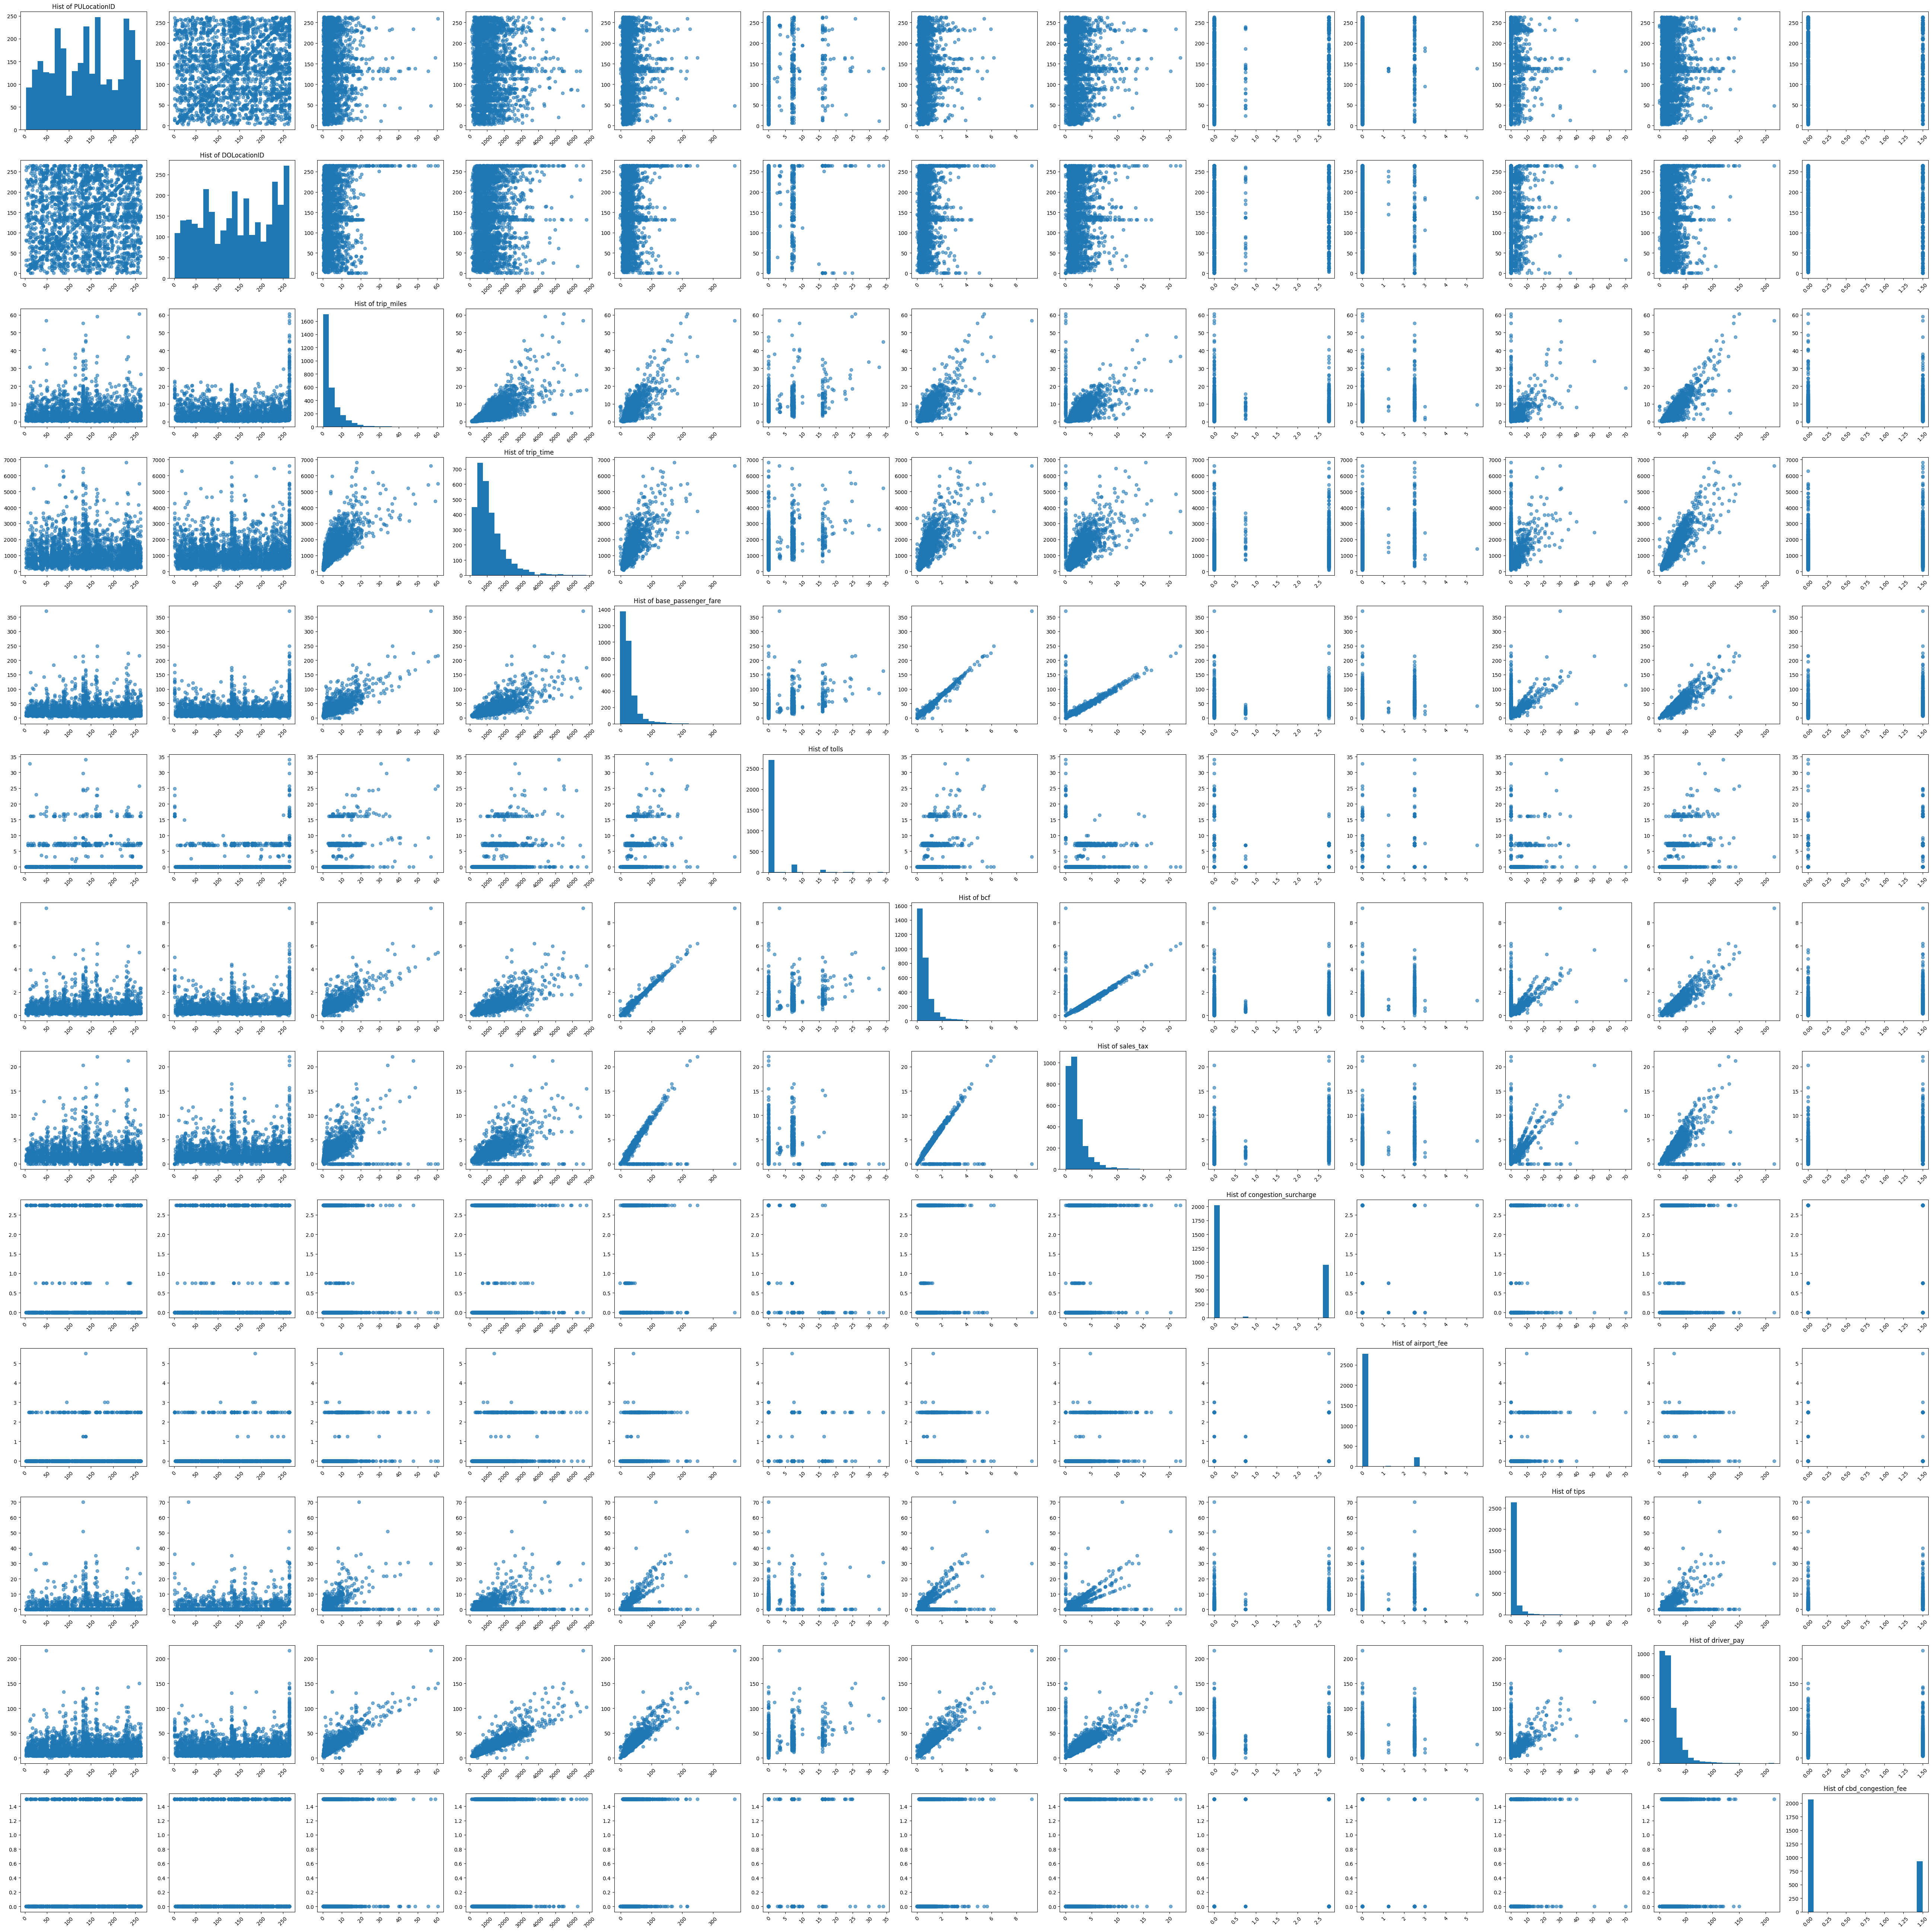

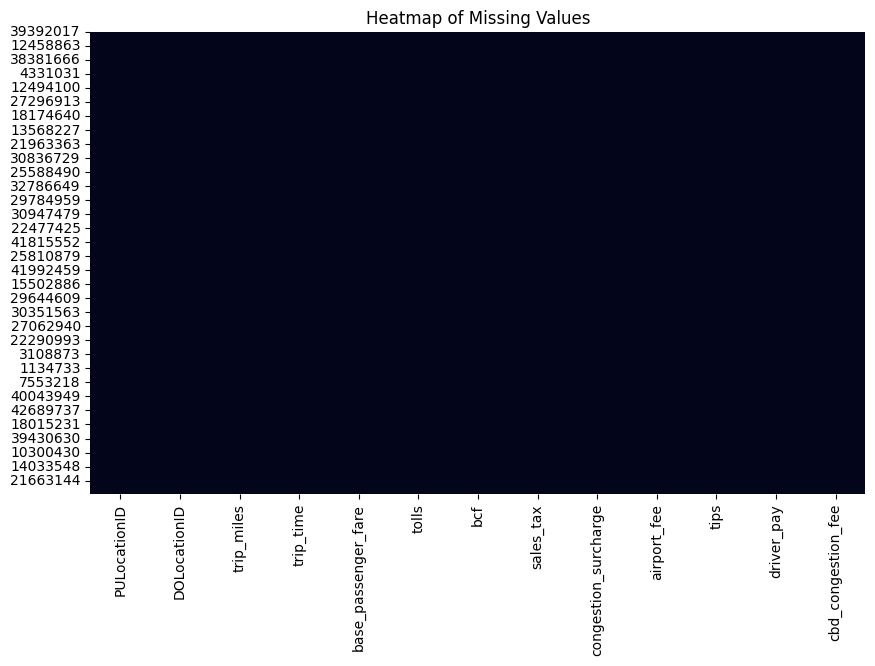

In [ ]:
# Since the dataset is very large (and after running the function on the whole dataset for more than 2 hour we did no  get any results, we ran this function on a subset of this dataset including 3000 random datas, and only the numerical features
df_vizDD = df.sample(n=3_000, random_state=42)
df_vizDD = df_vizDD.select_dtypes(include='number')

vizDDA(df_vizDD)